In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")

In [6]:
using SSMCMain.ModifiedMiCRM.MinimalModelV3

In [16]:
using Optim

In [7]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

In [5]:
ks = range(0.01, 100, 1000)
for gi in 1:5
    f = jldopen("./main3/gi$gi.jld2")
    df = f["df"]
    fmd = f["metadata"];
    N = fmd.N
    M = fmd.M

    # df = @subset df :retcodes .== ReturnCode.Success
    df = @subset df :maxresids .< 1e-10
    @show nrow(df), fmd.num_runs

    fit_ds_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    add_mm_mrls_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    
    @show count(df.spatially_unstable)
    
    fig_title = @sprintf "File: %s, K=%.5g, l=%.5g, p=%.5g" basename(f.path) fmd.K fmd.l fmd.p

    # Scatter plot
    fap = scatter(df.num_surv, 1 ./ df.fit_ds;
        # color=clamp.(df.fit_quality, 0., maximum(filter(<(1e-2), df.fit_quality); init=Inf)),
        # color=df.fit_quality,
        # colorscale=log10,
    )
    # Colorbar(fap.figure[1,2], fap.plot;
        # label="fit mismatch abs(delta peak height)"
    # )

    fap.axis.title = fig_title
    fap.axis.xlabel = "Number of surviving species"
    fap.axis.ylabel = "1 / fitted d parameter"

    mm = maximum(df.num_surv)
    lines!(fap.axis, [0., mm], [0., mm]; color=:black)

    Makie.save("./main3/corr_gi$gi.pdf", fap)
    
    # Fit quality plot
    fap = scatter(df.fit_quality, rand(nrow(df));
        figure=(; size=(600, 200)),
        axis=(; xscale=log10, title=fig_title),
        color=df.mmrls,
    )
    Colorbar(fap.figure[1,2], fap.plot; label="mmrls")
    ylims!(fap.axis, -0.5, 1.5)
    Makie.save("./main3/fitq_gi$gi.pdf", fap)

    # Show a couple of dispersion relations
    fig = plot_fitted_disprels(df, ks, 10;
        legend=true,
        axis=(; title=fig_title)
    )
    Makie.save("./main3/sample_disprels_gi$gi.pdf", fig.figure)
    fig
end

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 ~/.julia/packages/JLD2/WDhXU/src/JLD2.jl:162

LoadError: SystemError: opening file "./main3/gi1.jld2": No such file or directory

In [25]:
ks = range(0.01, 100, 1000)
for ri in 1:5
    f = jldopen("./main2/ri$ri.jld2")
    df = f["df"]
    fmd = f["metadata"];
    N = fmd.N
    M = fmd.M

    # df = @subset df :retcodes .== ReturnCode.Success
    df = @subset df :maxresids .< 1e-10
    @show nrow(df), fmd.num_runs

    fit_ds_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    add_mm_mrls_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    
    @show count(df.spatially_unstable)
    
    fig_title = @sprintf "File: %s, K=%.5g, l=%.5g, p=%.5g" basename(f.path) fmd.K fmd.l fmd.p

    # Scatter plot
    fap = scatter(df.num_surv, 1 ./ df.fit_ds;
        # color=clamp.(df.fit_quality, 0., maximum(filter(<(1e-2), df.fit_quality); init=Inf)),
        # color=df.fit_quality,
        # colorscale=log10,
    )
    # Colorbar(fap.figure[1,2], fap.plot;
        # label="fit mismatch abs(delta peak height)"
    # )

    fap.axis.title = fig_title
    fap.axis.xlabel = "Number of surviving species"
    fap.axis.ylabel = "1 / fitted d parameter"

    mm = maximum(df.num_surv)
    lines!(fap.axis, [0., mm], [0., mm]; color=:black)

    Makie.save("./main2/corr_ri$ri.pdf", fap)
    
    # Fit quality plot
    fap = scatter(df.fit_quality, rand(nrow(df));
        figure=(; size=(600, 200)),
        axis=(; xscale=log10, title=fig_title),
        color=df.mmrls,
    )
    Colorbar(fap.figure[1,2], fap.plot; label="mmrls")
    ylims!(fap.axis, -0.5, 1.5)
    Makie.save("./main2/fitq_ri$ri.pdf", fap)

    # Show a couple of dispersion relations
    fig = plot_fitted_disprels(df, ks, 10;
        legend=true,
        axis=(; title=fig_title)
    )
    Makie.save("./main2/sample_disprels_ri$ri.pdf", fig.figure)
    fig
end

(nrow(df), fmd.num_runs) = (99, 100)
count(df.spatially_unstable) = 0(nrow(df), fmd.num_runs) = (92, 100)
count(df.spatially_unstable) = 88(nrow(df), fmd.num_runs) = (85, 100)
count(df.spatially_unstable) = 83(nrow(df), fmd.num_runs) = (91, 100)
count(df.spatially_unstable) = 87(nrow(df), fmd.num_runs) = (90, 100)
count(df.spatially_unstable) = 80

In [8]:
f = jldopen("./main1/gi57.jld2")
# f = jldopen("./main2/ri4.jld2")
df = f["df"]
df = @subset df :retcodes .== ReturnCode.Success :num_surv .!= 0
fmd = f["metadata"];
@show fmd.K, fmd.l, fmd.p
nrow(df), fmd.num_runs

(fmd.K, fmd.l, fmd.p) = (27.371708245126285, 0.999, 1.0)

(23, 25)

In [86]:
ks = 10 .^ range(1., 3, 100);
@time add_disprels!(df, ks);

  0.097197 seconds (31.28 k allocations: 84.763 MiB)

# Testing

In [367]:
"""
    symlog10(linthresh)

Symlog-style Makie scale: linear inside `±linthresh`, log10 outside, joined
smoothly as `y -> sign(y) * log10(1 + |y|/linthresh)`. Every factor of 10 above
`linthresh` gets one unit of axis space, so both signs and many decades of
magnitude fit on one axis. Pair with `symlog10_ticks`/`symlog10_minorticks`
(or just use `symlog10_kwargs`) - Makie's automatic ticks fall back to linearly
spaced values for any non-log scale, which is what makes a bare symlog axis
look wrong.
"""
function symlog10(linthresh)
    t = float(linthresh)
    t > 0. || throw(ArgumentError("linthresh must be positive"))
    forward = y -> sign(y) * log10(1. + abs(y)/t)
    inverse = z -> sign(z) * t * (exp10(abs(z)) - 1.)
    Makie.ReversibleScale(forward, inverse; limits=(-3f0, 3f0), name=:symlog10)
end

function symlog10_ticklabel(v)
    v == 0. && return rich("0")
    e = round(Int, log10(abs(v)))
    sgn = v < 0. ? Makie.MINUS_SIGN : ""
    rich(sgn * "10", superscript(replace(string(e), "-" => Makie.MINUS_SIGN);
        offset=Vec2f(0.1, 0.)))
end

"""
    symlog10_ticks(linthresh; max_ticks=11)

Ticks at 0 and ±10^n from `linthresh` up, thinned to at most `max_ticks`.
"""
function symlog10_ticks(linthresh; max_ticks=11)
    e0 = round(Int, log10(float(linthresh)))
    (vmin, vmax) -> begin
        hi = max(abs(vmin), abs(vmax))
        emax = max(hi > 0. ? floor(Int, log10(hi)) : e0, e0)
        estep = max(1, cld(2*(emax - e0 + 1) + 1, max_ticks))
        vals = [0.]
        for e in e0:estep:emax
            push!(vals, 10.0^e, -10.0^e)
        end
        sort!(vals)
        filter!(v -> vmin <= v <= vmax, vals)
        vals, symlog10_ticklabel.(vals)
    end
end

"""
    symlog10_minorticks(linthresh; ndecades=12)

Minor ticks at ±(2:9)·10^n over `ndecades` decades starting at `linthresh`.
"""
function symlog10_minorticks(linthresh; ndecades=12)
    e0 = round(Int, log10(float(linthresh)))
    vals = Float64[]
    for e in e0:(e0 + ndecades), m in 2:9
        push!(vals, m * 10.0^e, -m * 10.0^e)
    end
    sort!(vals)
end

"""
    symlog10_linthresh(vals...; floor_frac=1e-6)

Pick a linthresh for `vals`: the nearest decade to the smallest nonzero magnitude,
but never more than `floor_frac` below the largest one.
"""
function symlog10_linthresh(vals...; floor_frac=1e-6)
    as = filter(>(0.), abs.(reduce(vcat, map(collect, vals))))
    isempty(as) && return 1.
    10.0^round(Int, log10(max(minimum(as), floor_frac * maximum(as))))
end

"""
    symlog10_kwargs(linthresh; dim=:y, kwargs...)

All the `Axis` kwargs needed for a symlog `dim` axis at once, e.g.
`Axis(fig[1,1]; symlog10_kwargs(1e-6)...)`.
"""
function symlog10_kwargs(linthresh; dim=:y, max_ticks=11, ndecades=12, minorgrid=false)
    kwargs = (;
        scale=symlog10(linthresh),
        ticks=symlog10_ticks(linthresh; max_ticks),
        minorticks=symlog10_minorticks(linthresh; ndecades),
        minorticksvisible=true,
        minorgridvisible=minorgrid,
    )
    NamedTuple(Symbol(dim, k) => v for (k, v) in pairs(kwargs)) # prefix each key with dim
end


symlog10_kwargs

In [368]:
function faf(xs, thr=1e-5)
    map(xs) do x
        if abs(x) < thr
            x
        else
            sign(x) * log10(abs(x))
        end
    end
end

faf (generic function with 2 methods)

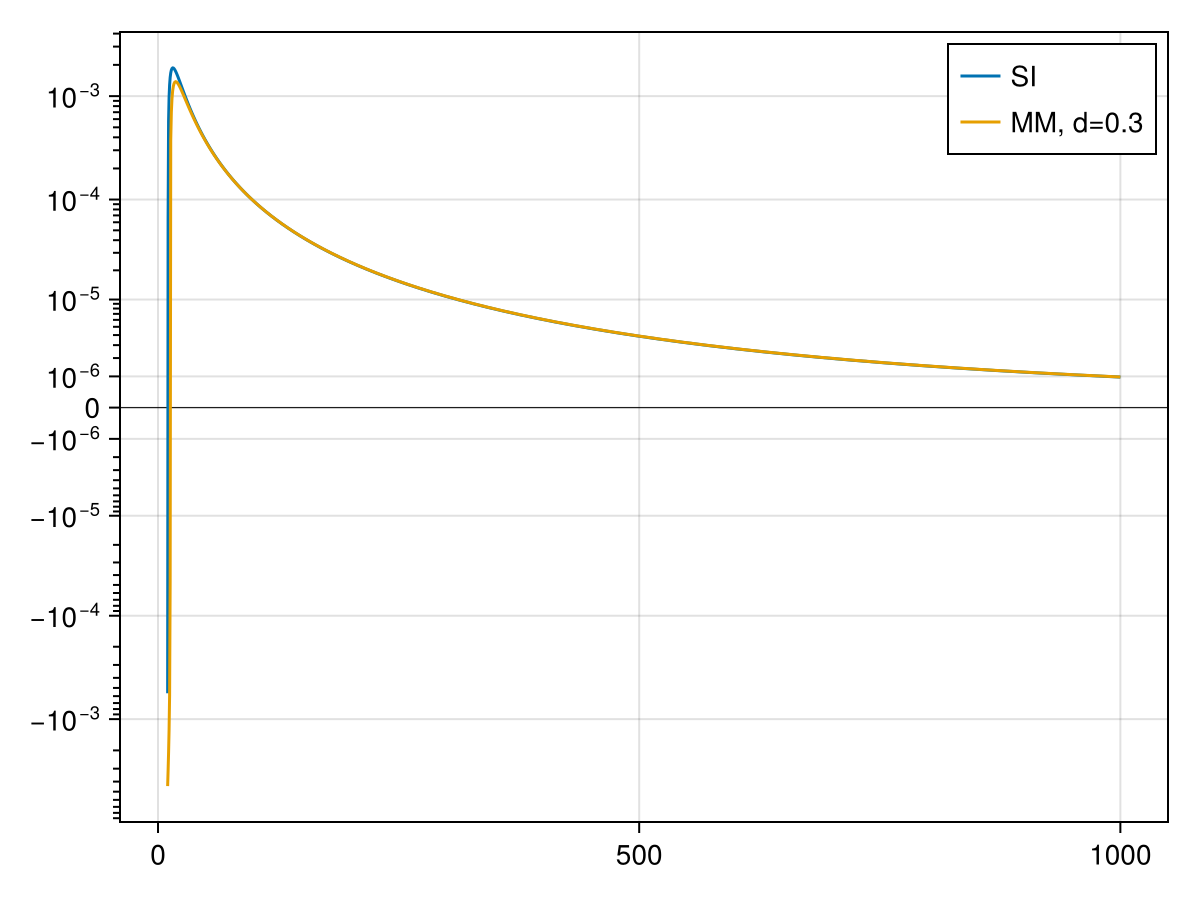

In [433]:
r = df[12,:];

mmp = MMParams(;
    K=fmd.K,
    m=1.,
    c=1.,
    l=fmd.l,
    d=0.3,
);
mm_hss = mmv3_get_hss_unique(mmp)
mmls = fr3_disprel_simple(mmp, 0., 1., fmd.p, mm_hss[1], ks);

linthresh = symlog10_linthresh(r.mrls, mmls) # or set by hand, e.g. 1e-6

fig = Figure()
ax = Axis(fig[1,1];
    # xscale=log10,
    symlog10_kwargs(linthresh)...,
)
hlines!(ax, [0.]; color=:black, linewidth=0.5)
lines!(ax, ks, r.mrls; label="SI")
lines!(ax, ks, mmls; label=(@sprintf "MM, d=%.6g" mmp.d))
axislegend(ax; position=:rt)
# xlims!(ax, 0., 200)
# display(GLMakie.Screen(), fig)
fig


# Optimizing d version 2

peak_offset(lo) = -9
peak_offset(hi) = 69
d_opt = 0.22158630098047485
ks[si_i] = 15.199110829529339
ks[(findmax(mmls))[2]] = 15.199110829529339

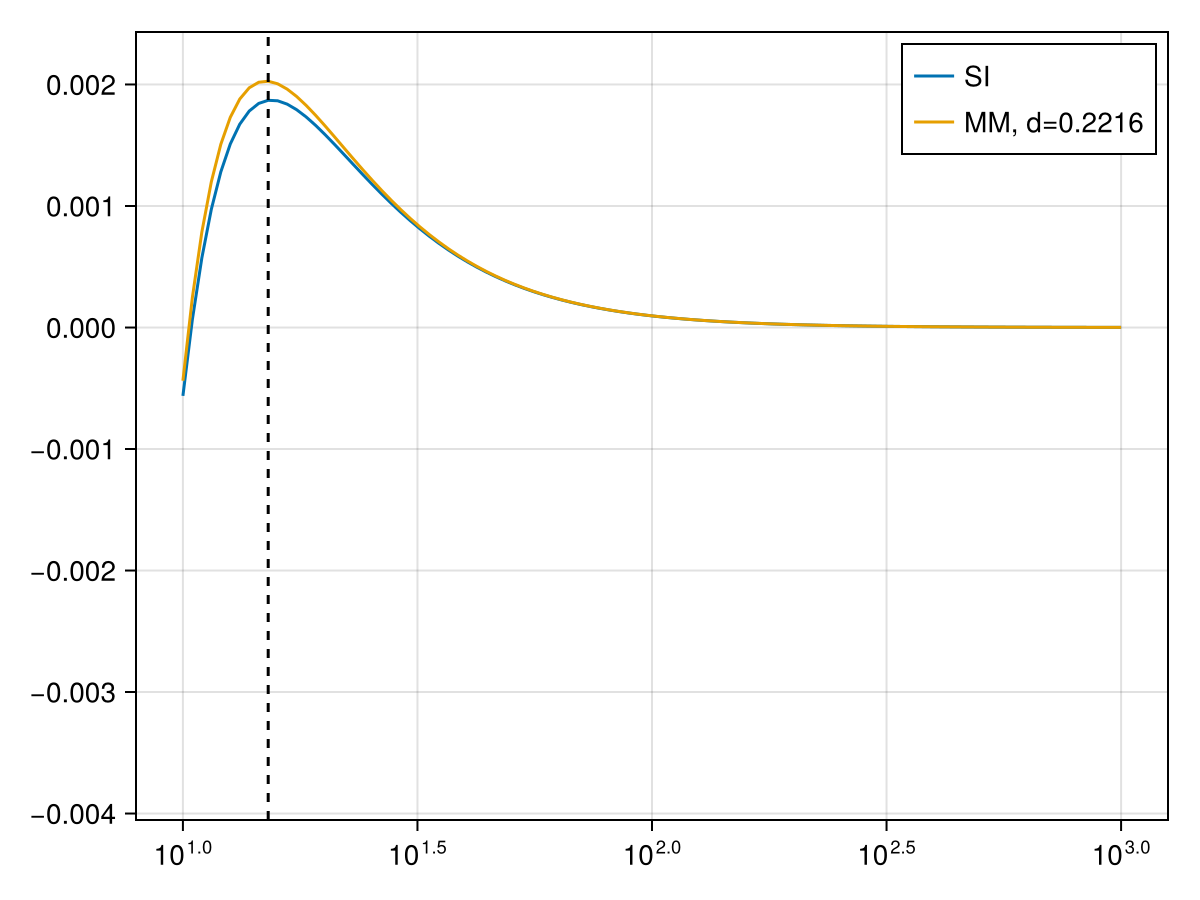

In [439]:
using Roots

r = df[12,:]

# Fit d by root-finding so the MM disprel peaks at the same k as the SI one
si_i = findmax(r.mrls)[2]

# where the MM peak sits relative to the SI peak, in grid points
peak_offset = logd -> begin
    mmp = MMParams(; K=fmd.K, m=1., c=1., l=fmd.l, d=10^logd)
    hss = mmv3_get_hss_unique(mmp)
    mmls = fr3_disprel_simple(mmp, 0., 1., fmd.p, hss[1], ks)
    findmax(mmls)[2] - si_i
end

lo, hi = -5., 2. # bracket in log10 d, the offset has to change sign across it
@show peak_offset(lo) peak_offset(hi)

d_opt = 10^find_zero(peak_offset, (lo, hi), Roots.Bisection())
@show d_opt

mmp = MMParams(; K=fmd.K, m=1., c=1., l=fmd.l, d=d_opt)
mmls = fr3_disprel_simple(mmp, 0., 1., fmd.p, mmv3_get_hss_unique(mmp)[1], ks)
@show ks[si_i] ks[findmax(mmls)[2]]

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)
lines!(ax, ks, r.mrls; label="SI")
lines!(ax, ks, mmls; label=(@sprintf "MM, d=%.4g" d_opt))
vlines!(ax, ks[si_i]; color=:black, linestyle=:dash)
axislegend(ax)
mm = abs(max(maximum(r.mrls), maximum(mmls)))
ylims!(ax, (-2., 1.2) .* mm)
# display(GLMakie.Screen(), fig)
fig

# Optimizing d version 1

d_opt = 0.2330000483902291
Optim.minimum(opt_r) = 0.012898531162624067
(si_k, si_h) = (15.199110829529339, 0.0018698541734879187)
(ks[mm_i], mm_h) = (15.199110829529339, 0.0018939725458142153)

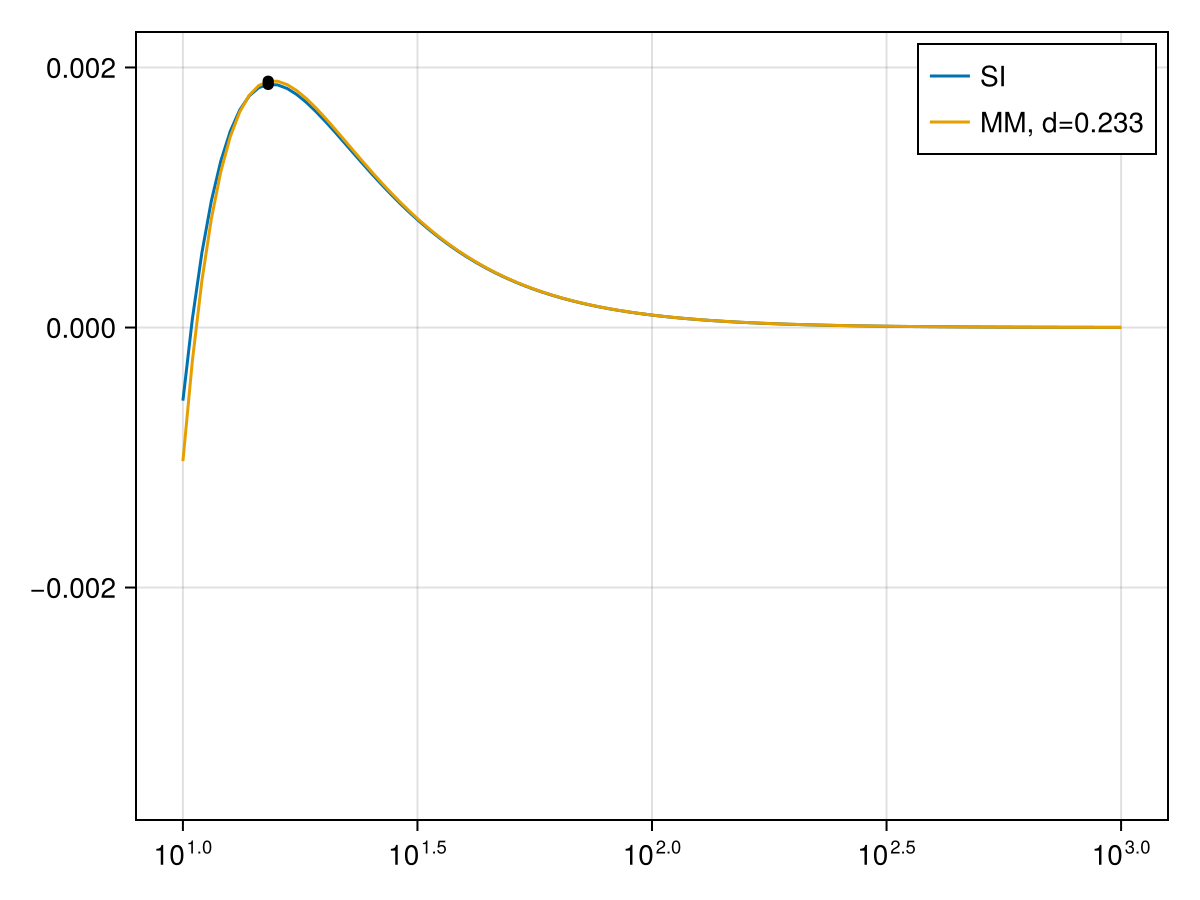

In [446]:
using Optim

r = df[12,:];
kweight = 1e5 # 0 -> peak height only, large -> peak location only

si_h, si_i = findmax(r.mrls)
si_k = ks[si_i]

obj = logd -> begin
    mmp = MMParams(; K=fmd.K, m=1., c=1., l=fmd.l, d=10^logd)
    hss = mmv3_get_hss_unique(mmp)
    hss[1] < 1e-9 && return Inf # extinct hss -> disprel is identically 0
    mm_h, mm_i = findmax(fr3_disprel_simple(mmp, 0., 1., fmd.p, hss[1], ks))
    # abs(mm_h - si_h) / abs(si_h) + kweight * abs(log(ks[mm_i] / si_k))
    (abs(mm_h - si_h) / abs(si_h)) + kweight * (abs(ks[mm_i] - si_k) / abs(si_k))
end

# opt_r = optimize(obj, -5., 5.) # plain Brent stalls on the staircase plateaus
logds = range(-5., 5., 100)
_, bi = findmin(obj.(logds)) # bracket the minimum first
opt_r = optimize(obj, logds[max(bi-1, 1)], logds[min(bi+1, end)])
d_opt = 10^Optim.minimizer(opt_r)
@show d_opt Optim.minimum(opt_r)

mmp = MMParams(; K=fmd.K, m=1., c=1., l=fmd.l, d=d_opt)
mmls = fr3_disprel_simple(mmp, 0., 1., fmd.p, mmv3_get_hss_unique(mmp)[1], ks)
mm_h, mm_i = findmax(mmls)
@show (si_k, si_h) (ks[mm_i], mm_h)

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)
lines!(ax, ks, r.mrls; label="SI")
lines!(ax, ks, mmls; label=(@sprintf "MM, d=%.6g" d_opt))
scatter!(ax, [si_k, ks[mm_i]], [si_h, mm_h]; color=:black, markersize=8)
axislegend(ax)
mm = abs(max(maximum(r.mrls), maximum(mmls)))
ylims!(ax, (-2., 1.2) .* mm)
fig

# Optimizing d version 3

In [27]:
"""
    fit_mm_d(si_params, si_fs, si_Ds, K, l, p, ks, kweight=1e5)

Fit the MM d by matching its disprel peak to that of the given SI system, both peaks
located numerically. Returns (; d, si_mrls, mmls, si_k, mm_k) with the disprels
evaluated on the passed ks and si_k/mm_k the two peak locations, or nothing if the
SI system is not spatially unstable.
"""
function fit_mm_d(si_params, si_fs, si_Ds, K, l, p, ks, kweight=1e5;
    m=1., c=1., DN=0., DI=1., extinct_threshold=1e-9, logdlims=(-6., 5.),
)
    si_mrls = linstab_simple(si_params, si_Ds, si_fs, ks)
    si_h0, i = findmax(si_mrls)
    si_h0 <= 0. && return nothing

    si_opt = optimize(log(ks[max(i-1, 1)]), log(ks[min(i+1, end)])) do logk
        -linstab_simple(si_params, si_Ds, si_fs, [exp(logk)])[1]
    end
    si_k, si_h = exp(Optim.minimizer(si_opt)), -Optim.minimum(si_opt)

    mm_peak = mmp -> begin
        hss = mmv3_get_hss_unique(mmp)
        (isempty(hss) || hss[1] < extinct_threshold) && return nothing
        j = findmax(fr3_disprel_simple(mmp, DN, DI, p, hss[1], ks))[2]
        mm_opt = optimize(log(ks[max(j-1, 1)]), log(ks[min(j+1, end)])) do logk
            -fr3_disprel_simple(mmp, DN, DI, p, hss[1], [exp(logk)])[1]
        end
        exp(Optim.minimizer(mm_opt)), -Optim.minimum(mm_opt)
    end

    obj = logd -> begin
        pk = mm_peak(MMParams(; K, l, m, c, d=10^logd))
        isnothing(pk) && return Inf
        mm_k, mm_h = pk
        abs(mm_h - si_h) / abs(si_h) + kweight * abs(mm_k - si_k) / abs(si_k)
    end

    opt_r = optimize(obj, logdlims...)
    if opt_r.minimizer in logdlims
        @warn "Hitting logdlims in optimization"
    end
    d = 10^Optim.minimizer(opt_r)

    mmp = MMParams(; K, l, m, c, d)
    mmls = fr3_disprel_simple(mmp, DN, DI, p, mmv3_get_hss_unique(mmp)[1], ks)
    mm_k, _ = mm_peak(mmp)
    (; d, si_mrls, mmls, si_k, mm_k)
end

fit_mm_d

In [28]:
ks = 10 .^ range(-6, 6, 1000)
r = df[12,:]
(fit_d, si_mrls, mmls) = fit_mm_d(r.params, r.final_states, r.Dss, fmd.K, fmd.l, fmd.p, ks, 1e5);

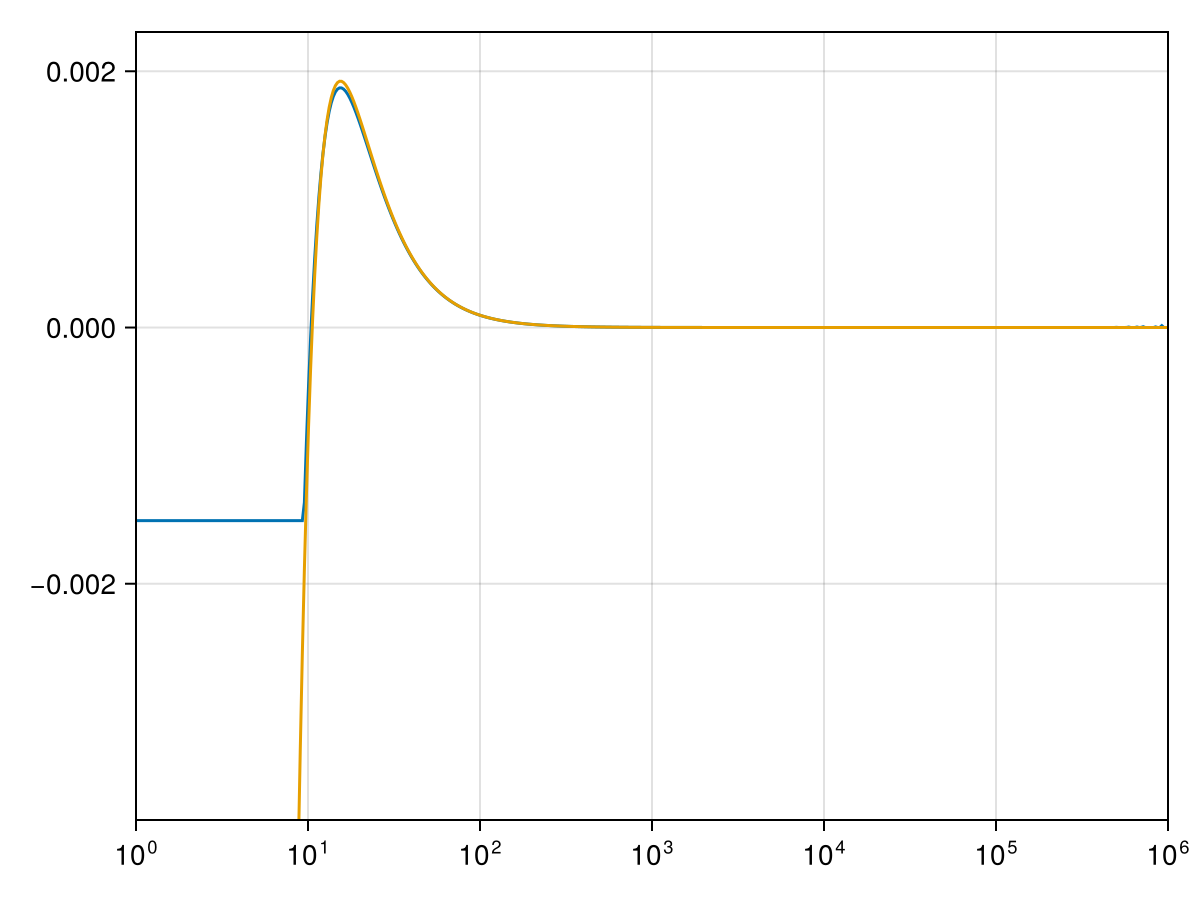

In [29]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)
lines!(ax, ks, si_mrls)
lines!(ax, ks, mmls)
mm = abs(max(maximum(si_mrls), maximum(mmls)))
xlims!(ax, 1e0, 1e6)
ylims!(ax, (-2., 1.2) .* mm)
# display(GLMakie.Screen(), fig)
fig